In [186]:
import sys
from pathlib import Path
import country_converter as coco
import matplotlib.pyplot as plt
import re
import pandas as pd
import math
import numpy as np
from uncertainties import ufloat, nominal_value, std_dev
from uncertainties.core import CallableStdDev
import plotly.express as px

# ---------------------------- Run from Repo Root ----------------------------
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# ---------------------------- File Paths ----------------------------
main_scale_up_path = BASE_DIR / "results" / "Scale_up_output_MS.csv"
percent_ecw_scale_up_path = BASE_DIR / "results" / "Scale_up_PERCENT_ECW_POLL_MS.csv"

cr_man_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_MAN_MS.csv"
cr_repur_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_REPUR_MS.csv"
cr_stock_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_STOCK.csv"
coalbag_scale_up_path = BASE_DIR / "results" / "Scale_up_COALBAG_MS.csv"

ecw_country = BASE_DIR / "results" / "ECWbyCountry.csv"
ecw_region = BASE_DIR / "results" / "ECWbyRegion.csv"

In [187]:
# ---------- Core Functions ----------

def get_series(df, region):
    """Return time (weeks), nominal values, and uncertainties for a single country."""
    if region not in df.index:
        raise ValueError(f"{region} not found in DataFrame index")

    row = df.loc[region]  # Series of ufloats
    row = row.iloc[2:]
    time = np.arange(len(row))
    values = np.array([nominal_value(v) for v in row])
    errors = np.array([std_dev(v) for v in row])
    return time, values, errors

def get_ECW(df, region):
    row = df.loc[region]
    ECW_Upper = row[1]
    ECW_Lower = row[0]
    return ECW_Lower, ECW_Upper

def plot_region(df, region, ax=None, sigma=1, show_CADR=True, percentage=False, show_start=False, export=False, file_path=None):
    """
    Plot a single country's series with ±sigma bands and optional CADR range.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    
    t, vals, errs = get_series(df, region)

    line, = ax.plot(t, vals, label=region, linewidth=2) 
    color = line.get_color()

    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, color=color, alpha=0.25)

    if show_CADR:
        ecw_lower, ecw_upper = get_ECW(df, region)
        CADR_lower = CADRPP * ecw_lower
        CADR_upper = CADRPP * ecw_upper
        ax.axhspan(CADR_lower, CADR_upper, color=color, alpha=0.12,
                   label=f'Critical Worker Range ({CADR_lower:.2e} - {CADR_upper:.2e})')

    if show_start:
        ax.set_xlim(0,20)
    
    if percentage: 
        ax.set_ylim(0,1)
        ax.set_ylabel("% of Critical Workers Covered", fontsize=10)
    else: 
        ax.set_ylabel("Clean Air Delivery Rate (L/s)", fontsize=10)

    ax.set_xlabel("Weeks", fontsize=10)
    ax.set_title(f"{region} Scale-Up with ±{sigma}σ Bands", fontsize=12, fontweight='bold')

    ax.grid(True, linestyle='--', alpha=0.4)

    ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, frameon=True, framealpha=0.9)    
    plt.tight_layout()

    if export and file_path is not None:
        file_path = Path(file_path)
        fig.savefig(file_path, dpi=300, bbox_inches='tight')

    return ax

def plot_multiple_regions(df, region, sigma=1, show_CADR=True,percentage = False, show_start = False, export=False, file_path = None):
    """Plot multiple regions together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for c in region:
        plot_region(df, c, ax=ax, sigma=sigma, show_CADR = show_CADR, percentage=percentage, show_start=show_start)
    plt.title(f"{region} series with ±{sigma}σ bands", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    if export and file_path is not None:
        file_path = Path(file_path)
        fig.savefig(file_path, dpi=300, bbox_inches='tight')

def plot_stacked_regions(df1, df2, df3, df4, region, ax=None,show_CADR=True,percentage = False, show_start = False, export=False, file_path = None):
    'Plot a stacked area chart for 4 dataframes for a given region.'
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t1, vals1, _ = get_series(df1, region)
    t2, vals2, _ = get_series(df2, region)
    t3, vals3, _ = get_series(df3, region)
    t4, vals4, _ = get_series(df4, region)
    
    t = t1  # assume all dfs have the same weeks
    
    if show_CADR:
        ecw_lower, ecw_upper = get_ECW(df1, region)
        CADR_lower = CADRPP * ecw_lower
        CADR_upper = CADRPP * ecw_upper
        ax.axhspan(CADR_lower, CADR_upper, alpha=0.15, 
                   label=f'Critical Worker Range ({CADR_lower:.2e} - {CADR_upper:.2e})')
    
    if percentage: 
        ax.set_ylim(0,1)
        ax.set_ylabel("% of Critical Workers Covered", fontsize=10)
    else: 
        ax.set_ylabel("Clean Air Delivery Rate: L/s", fontsize = 10)

    if show_start:
        ax.set_xlim(0,20)

    stack_vals = [vals1, vals2, vals3, vals4]
    
    labels = ['CR Box Repurposing', 'CR Box Stock', 'Coalbaghouse','CR Box Manufacturing']
    
    ax.stackplot(t, *stack_vals, labels=labels, alpha=0.6)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(f"{region} - Stacked Area Chart",fontweight='bold')
    ax.set_xlabel("Weeks", fontsize=10)
    ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, frameon=True, framealpha=0.9)    
    plt.tight_layout()

    if export and file_path is not None:
        file_path = Path(file_path)
        fig.savefig(file_path, dpi=300, bbox_inches='tight')
   
    return ax

In [188]:
## ---------------------------- Varaibles ---------------------------- 

CADRPP = 100 # L/s
UNRegion_list = ['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']

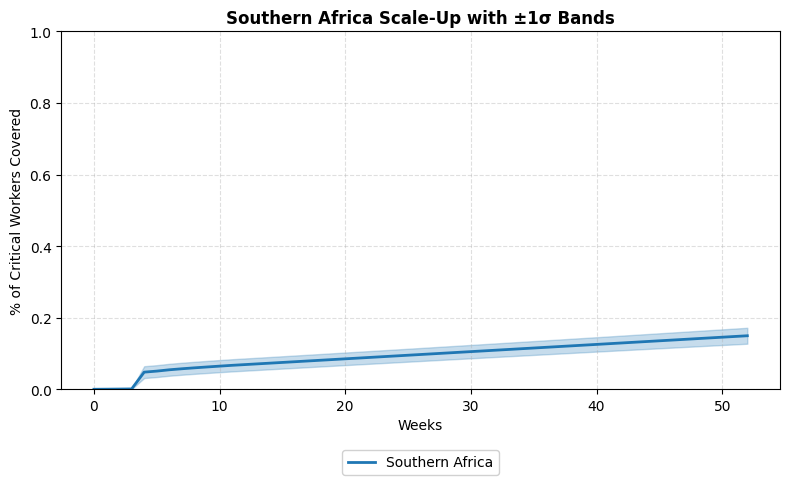

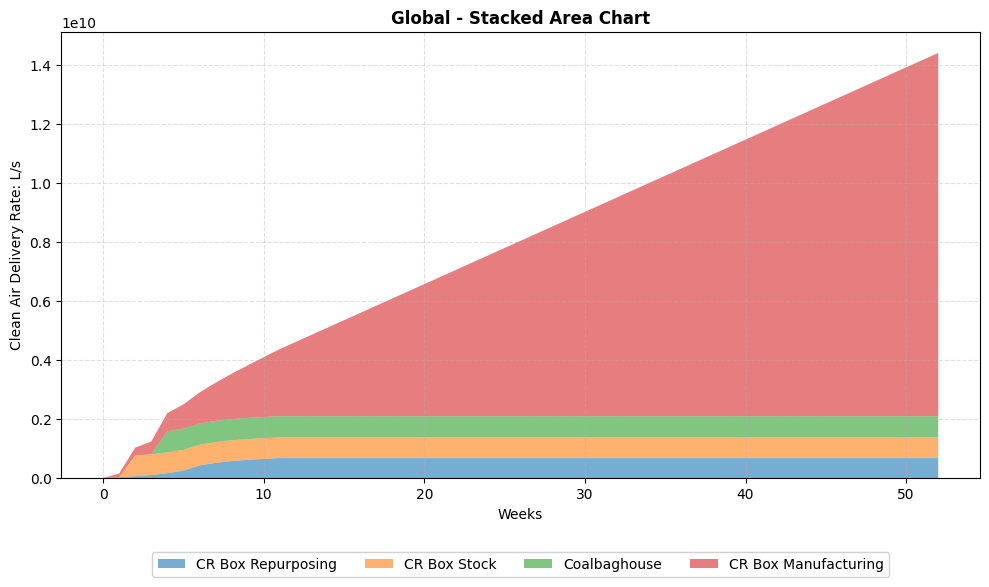

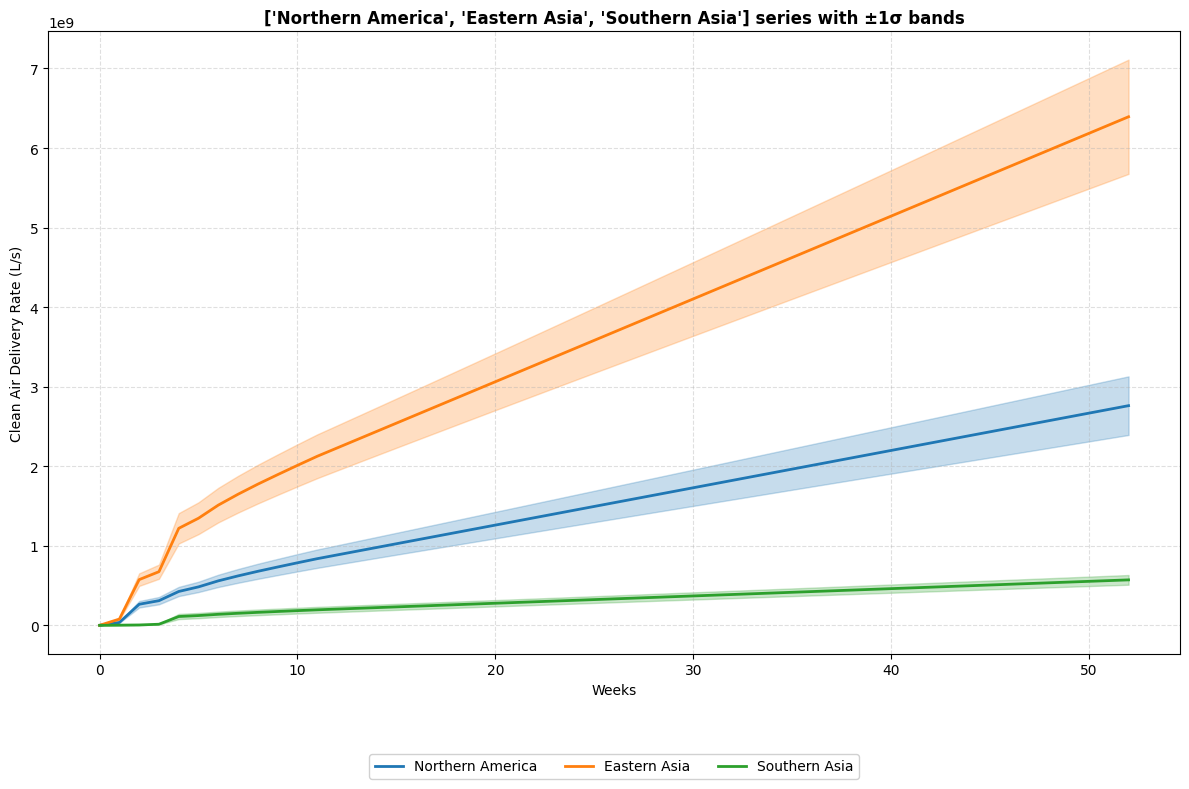

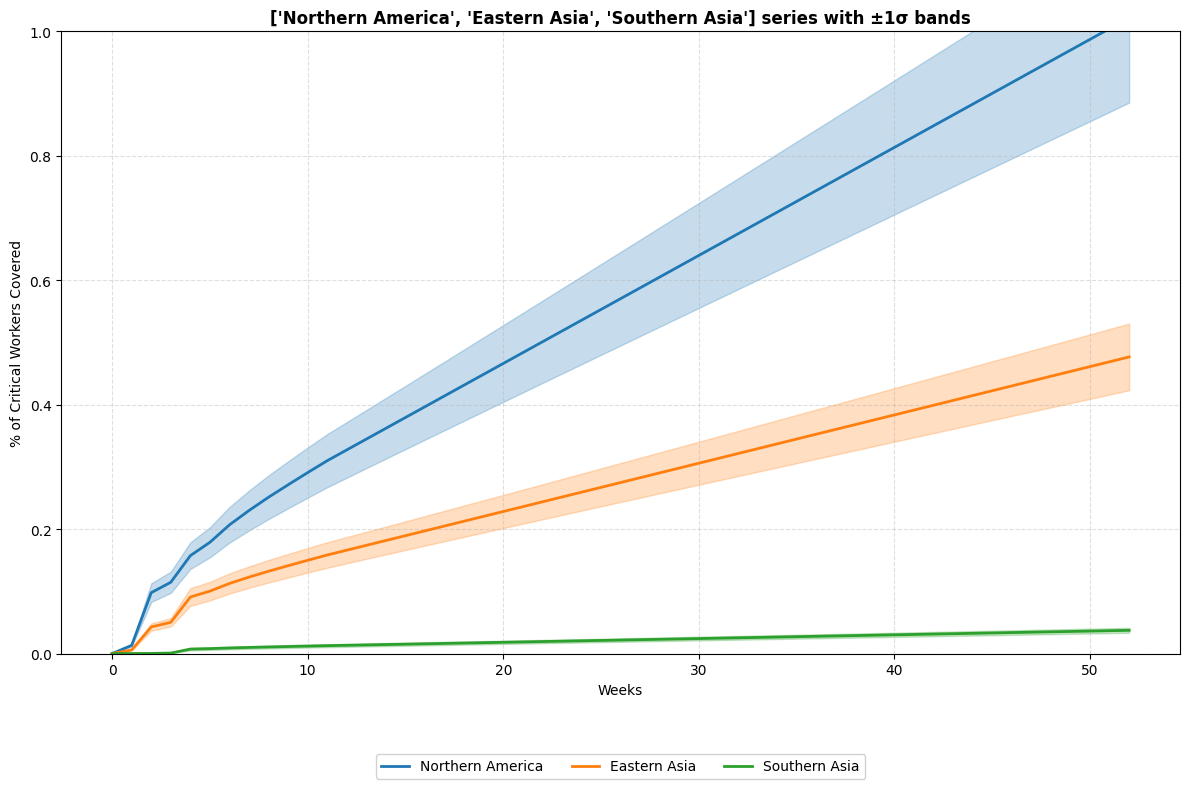

In [196]:
## ---------------------------- Scale Up Plotting for Tester ---------------------------- 
df_MAIN_loaded = pd.read_pickle(main_scale_up_path.with_suffix(".pkl"))
df_PERCENT_ECW_LOADED = pd.read_pickle(percent_ecw_scale_up_path.with_suffix(".pkl"))

df_CR_REPUR_loaded = pd.read_pickle(cr_repur_scale_up_path.with_suffix(".pkl"))
df_CR_STOCK_loaded = pd.read_pickle(cr_stock_scale_up_path.with_suffix(".pkl"))
df_COALBAG_loaded = pd.read_pickle(coalbag_scale_up_path.with_suffix(".pkl"))
df_CR_MAN_loaded = pd.read_pickle(cr_man_scale_up_path.with_suffix(".pkl"))


# ---------- Comparision ----------

# ---------------------------- Exporting Paths ----------------------------
output_image_folder = BASE_DIR / "results" / "Output Images" / "Comparison" / 'Figure 1'

plot_region(df_PERCENT_ECW_LOADED, 'Southern Africa', show_CADR=False, percentage=True)
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Global', show_CADR = False, export=True, file_path=output_image_folder)

plot_multiple_regions(df_MAIN_loaded, ['Northern America','Eastern Asia', 'Southern Asia'],show_CADR=False)
plot_multiple_regions(df_PERCENT_ECW_LOADED, ['Northern America','Eastern Asia', 'Southern Asia'],show_CADR=False, percentage=True)

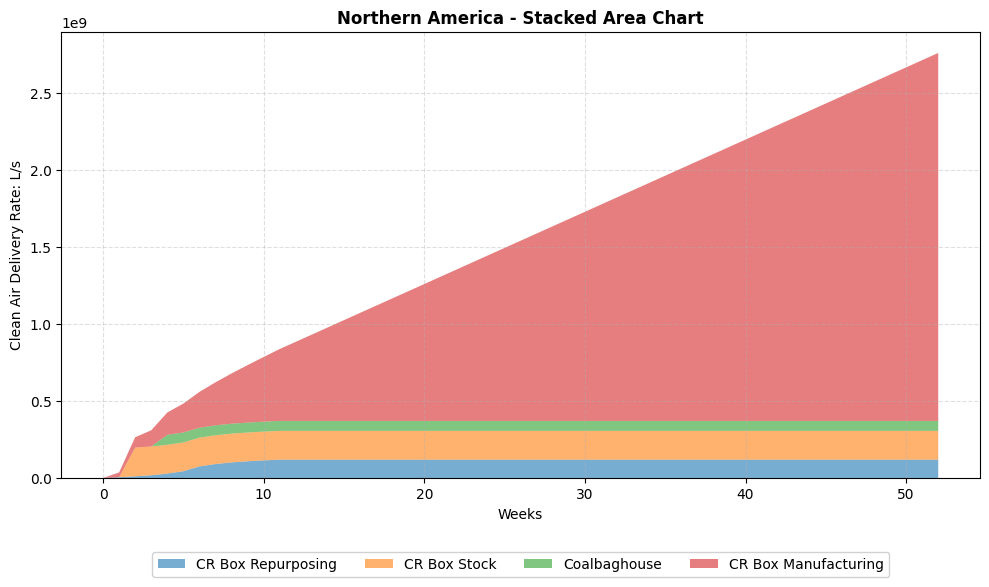

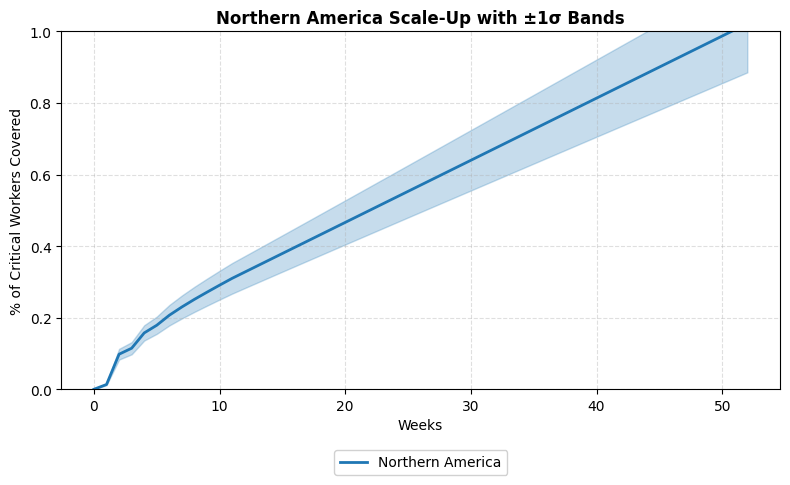

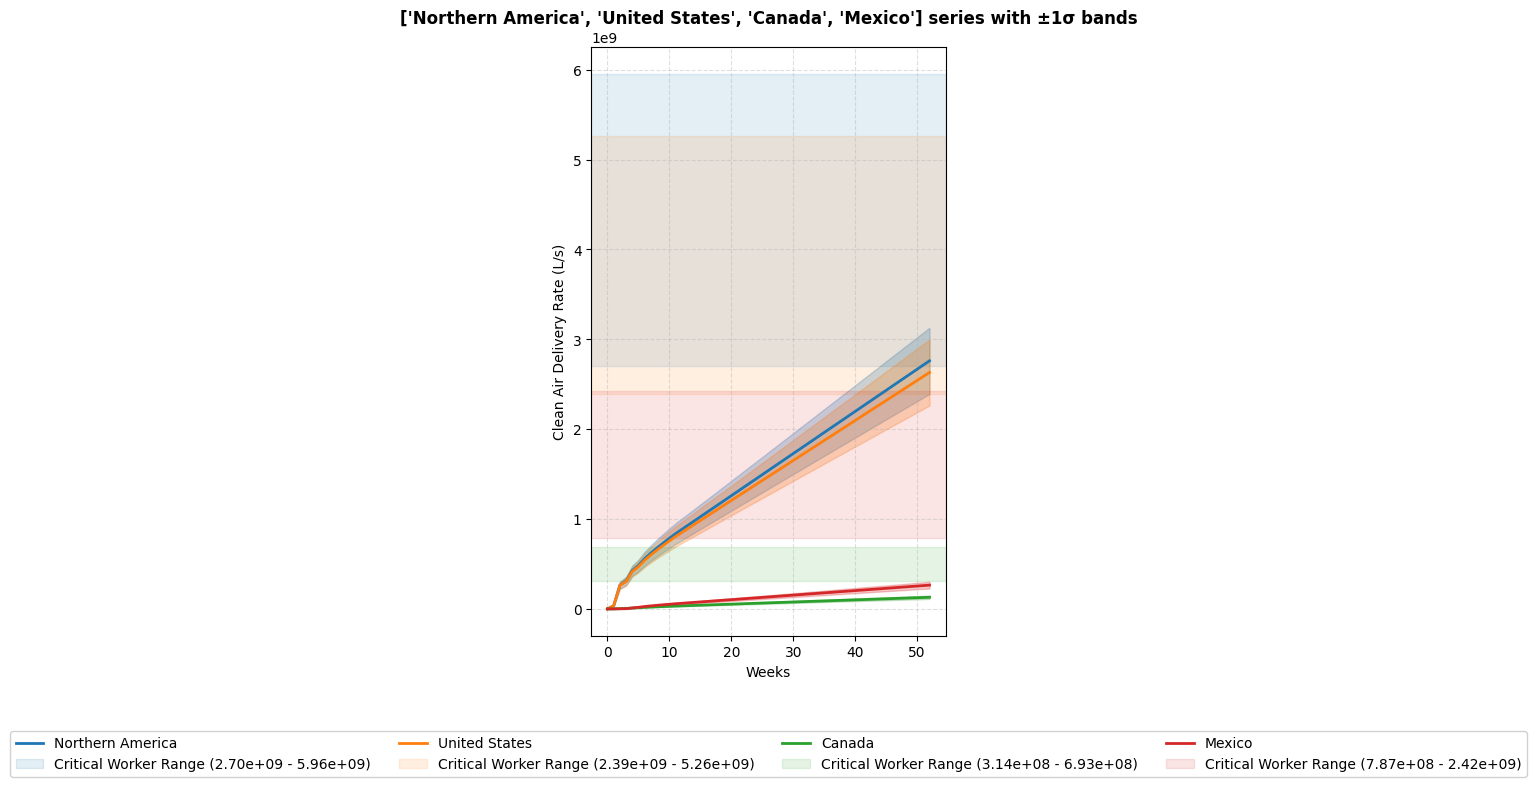

In [190]:
# ---------- Good Scale Up Scenario - Northern America ----------
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Northern America', show_CADR=False)
plot_region(df_PERCENT_ECW_LOADED, 'Northern America', sigma = 1, percentage = True, show_CADR = False)
plot_multiple_regions(df_MAIN_loaded, ['Northern America','United States', 'Canada', 'Mexico'],show_CADR=True)

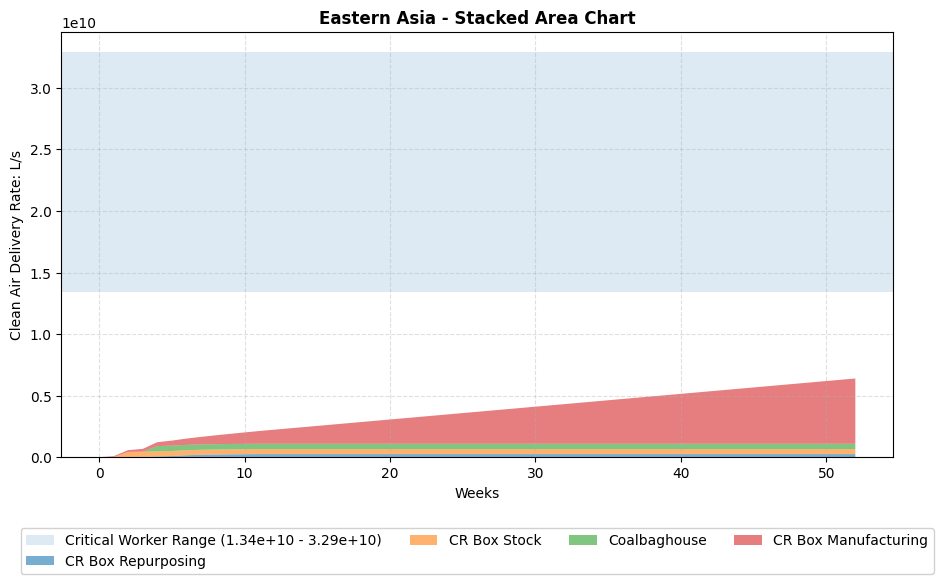

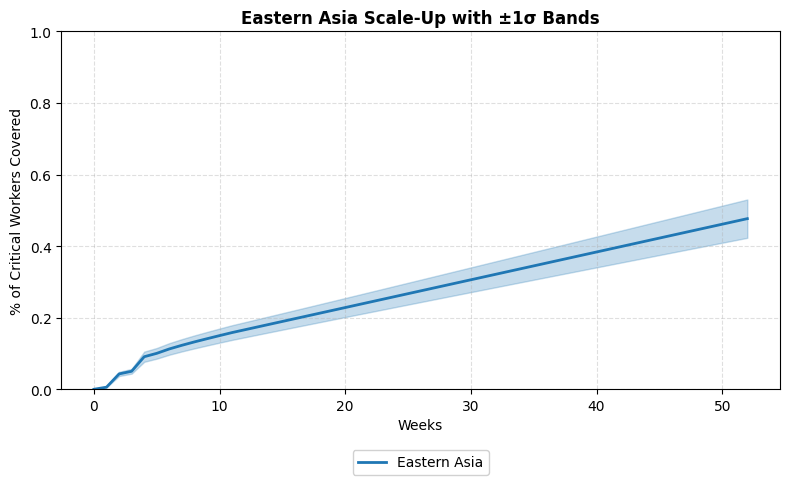

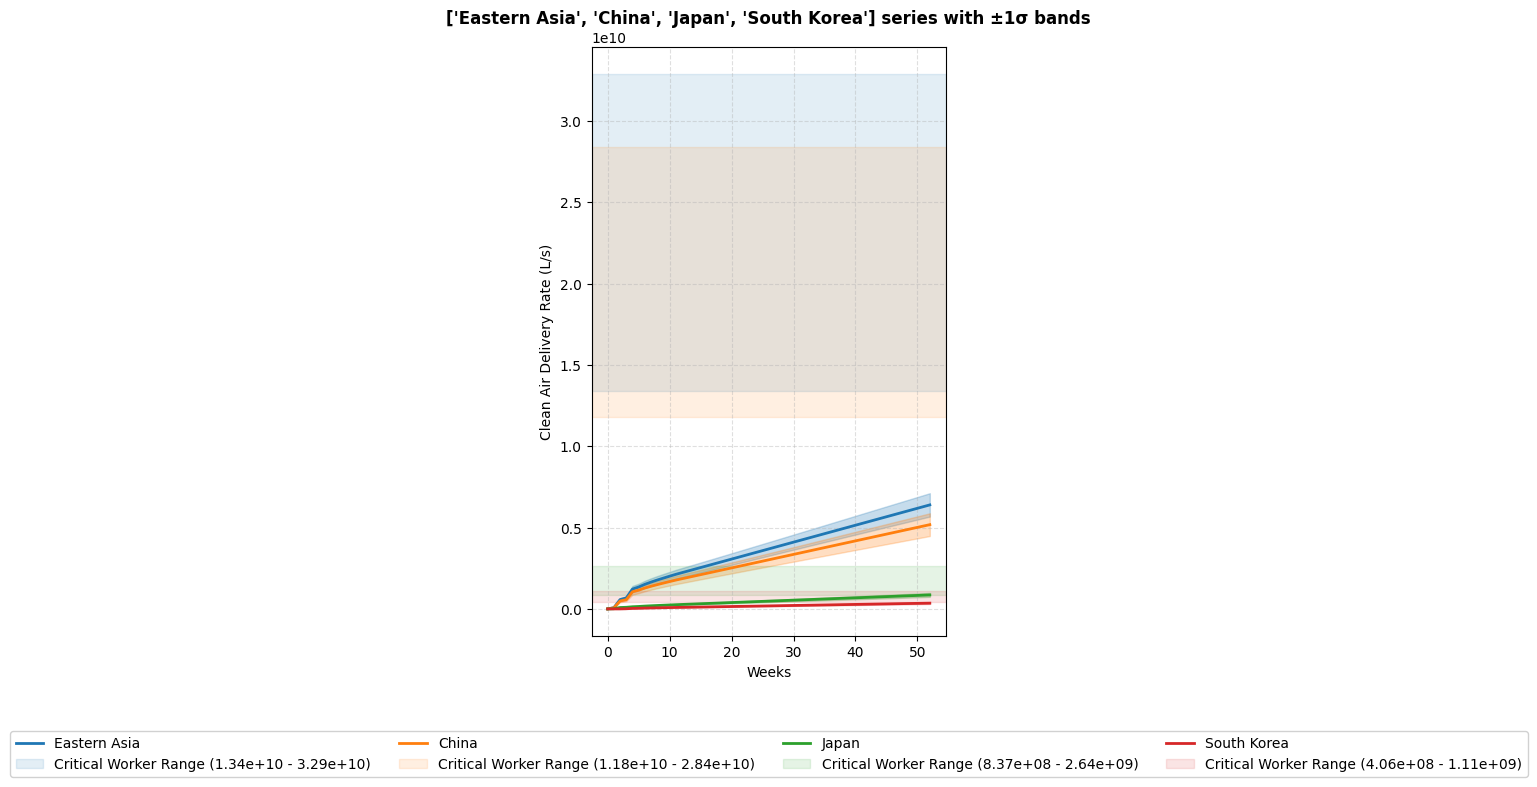

In [191]:
# ---------- Mid Scale Up Scenario - Eastern Asia ----------
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Eastern Asia')
plot_region(df_PERCENT_ECW_LOADED, 'Eastern Asia', percentage = True, show_CADR = False)
plot_multiple_regions(df_MAIN_loaded, ['Eastern Asia', "China", 'Japan', 'South Korea'], sigma =1, show_CADR=True)

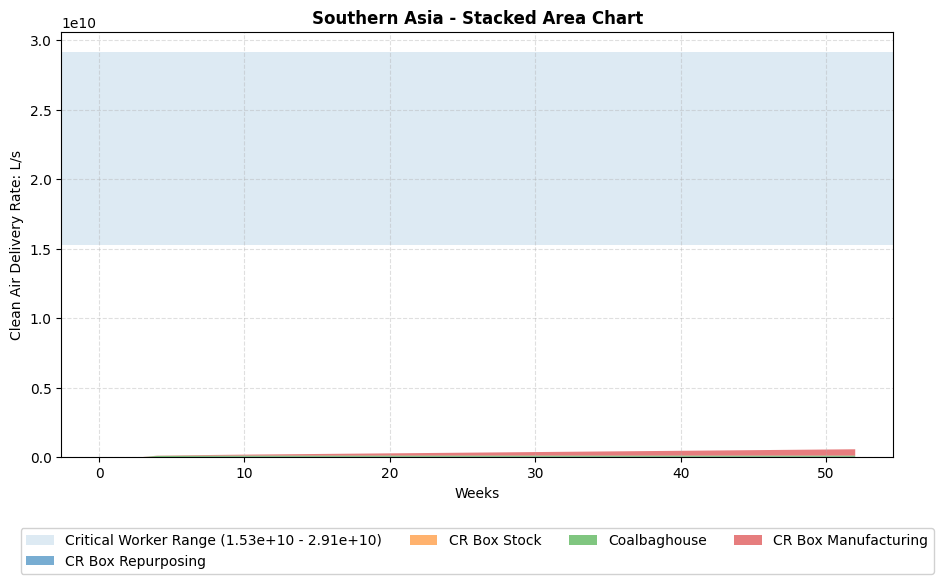

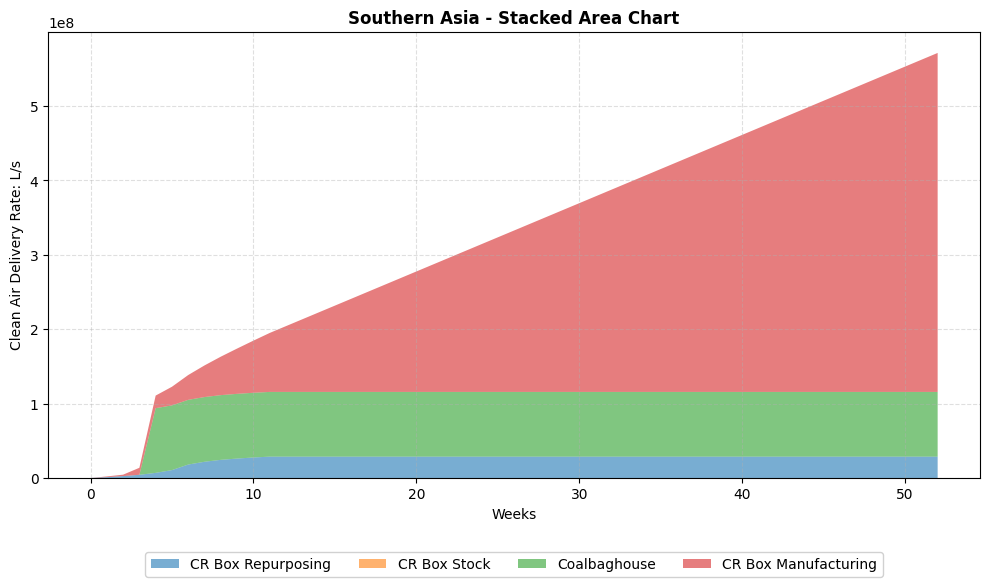

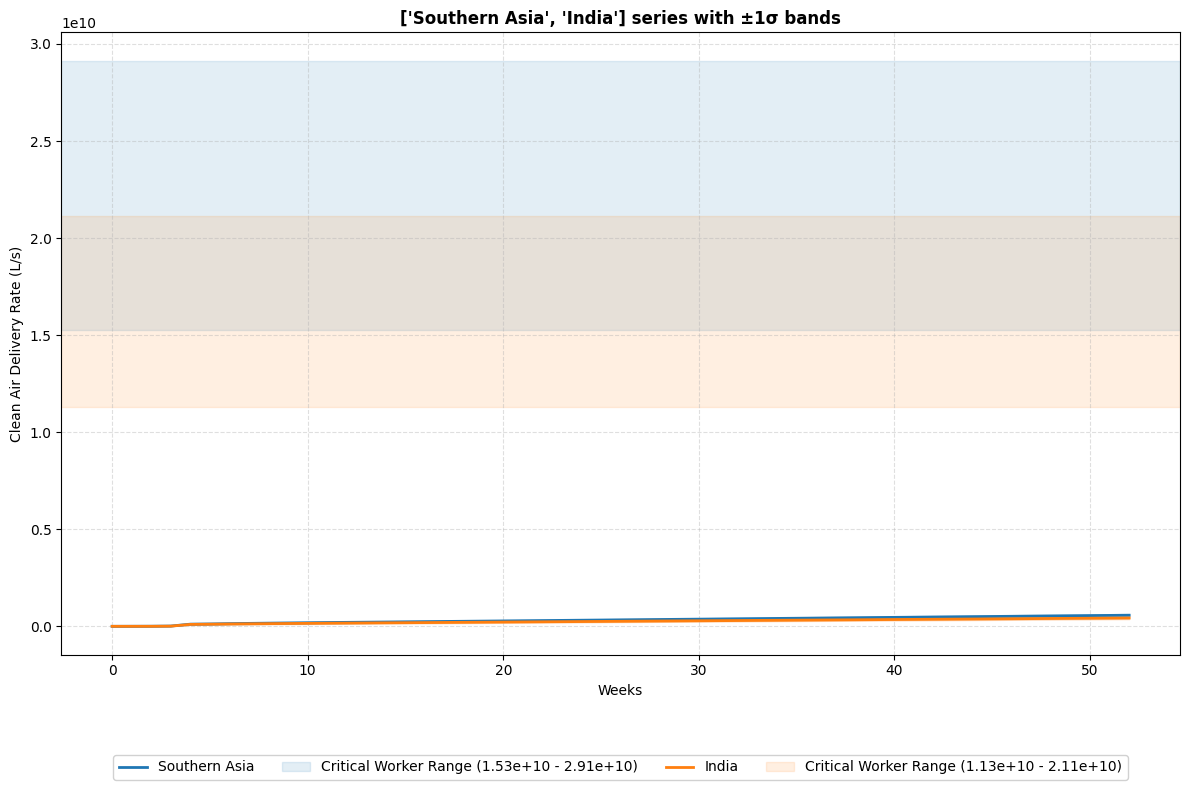

In [192]:
# ---------- Bad Scale Up Scenario - Southern Asia ----------
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Southern Asia')
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Southern Asia', show_CADR=False)

plot_multiple_regions(df_MAIN_loaded, ['Southern Asia', "India"], sigma =1 )

In [193]:
# for i in UNRegion_list:
#     plot_region(df_MAIN_loaded, i, sigma=1)
#     plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, i)